In [7]:
import os
import pandas as pd
import numpy as np
import taxonomia
import librosa 
import librosa.display
from pydub import AudioSegment
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [8]:
def obtener_paths_cantos(base_dir):
    data = []

    # Recorrer las familias
    for familia in os.listdir(base_dir):
        if familia == '.DS_Store':
            continue
        familia_path = os.path.join(base_dir, familia)
        if os.path.isdir(familia_path):
            # Recorrer los géneros
            for genero in os.listdir(familia_path):
                if genero == '.DS_Store':
                    continue
                genero_path = os.path.join(familia_path, genero)
                if os.path.isdir(genero_path):
                    # Recorrer las especies
                    for especie in os.listdir(genero_path):
                        if especie == '.DS_Store':
                            continue
                        especie_path = os.path.join(genero_path, especie)
                        if os.path.isdir(especie_path):
                            # Recorrer los nombres comunes
                            for nombre_comun in os.listdir(especie_path):
                                if nombre_comun == '.DS_Store':
                                    continue
                                nombre_comun_path = os.path.join(especie_path, nombre_comun)
                                if os.path.isdir(nombre_comun_path):
                                    # Recorrer los cantos
                                    for canto in os.listdir(nombre_comun_path):
                                        if canto == '.DS_Store':
                                            continue
                                        canto_path = os.path.join(nombre_comun_path, canto)
                                        if os.path.isfile(canto_path):
                                            data.append({
                                                'Specie': especie,
                                                'Genus': genero,
                                                'Family': familia,
                                                'audio_path': canto_path
                                            })

    # Crear el DataFrame
    df = pd.DataFrame(data)
    return df

# Definir la ruta base
base_dir = '/Users/camcortes/Documents/birds-sounds/notebooks/songs'

# Obtener el DataFrame
df = obtener_paths_cantos(base_dir)

# Mostrar el DataFrame
print(df.shape)
# ordenar por especie de forma descendente
df = df.sort_values(by=['Specie'], ascending=False)
df.head(4)


(80663, 4)


,Specie,Genus,Family,audio_path
78034,Zonotrichia leucophrys,Zonotrichia,Passerellidae,/Users/camcortes/Documents/birds-sounds/notebo...
78033,Zonotrichia leucophrys,Zonotrichia,Passerellidae,/Users/camcortes/Documents/birds-sounds/notebo...
78025,Zonotrichia leucophrys,Zonotrichia,Passerellidae,/Users/camcortes/Documents/birds-sounds/notebo...
78026,Zonotrichia leucophrys,Zonotrichia,Passerellidae,/Users/camcortes/Documents/birds-sounds/notebo...


In [9]:
def get_split_unique(path, base_filename):
    # Carga el archivo de audio
    try:
        audio = AudioSegment.from_file(path, "mp3")
    except Exception as e:
        print(f"Error al cargar el archivo de audio {path}: {e}")
        os.remove(path)
        return []

    return None

def get_split_with_label(row):
    path = row['audio_path']
    base_filename = os.path.splitext(os.path.basename(path))[0]
    chunk_paths = get_split_unique(path, base_filename)
    print(path)
    return None

#df.apply(get_split_with_label, axis=1)

In [10]:
familia = taxonomia.capitalize_family_genus(taxonomia.genus_family)
df['Family'] = df['Genus'].map(familia)
df['Suborder'] = df['Family'].map(taxonomia.suborder)

In [11]:
print(df.shape)
df.head()

(80663, 5)


,Specie,Genus,Family,audio_path,Suborder
78034,Zonotrichia leucophrys,Zonotrichia,Passerellidae,/Users/camcortes/Documents/birds-sounds/notebo...,passeri
78033,Zonotrichia leucophrys,Zonotrichia,Passerellidae,/Users/camcortes/Documents/birds-sounds/notebo...,passeri
78025,Zonotrichia leucophrys,Zonotrichia,Passerellidae,/Users/camcortes/Documents/birds-sounds/notebo...,passeri
78026,Zonotrichia leucophrys,Zonotrichia,Passerellidae,/Users/camcortes/Documents/birds-sounds/notebo...,passeri
78027,Zonotrichia leucophrys,Zonotrichia,Passerellidae,/Users/camcortes/Documents/birds-sounds/notebo...,passeri


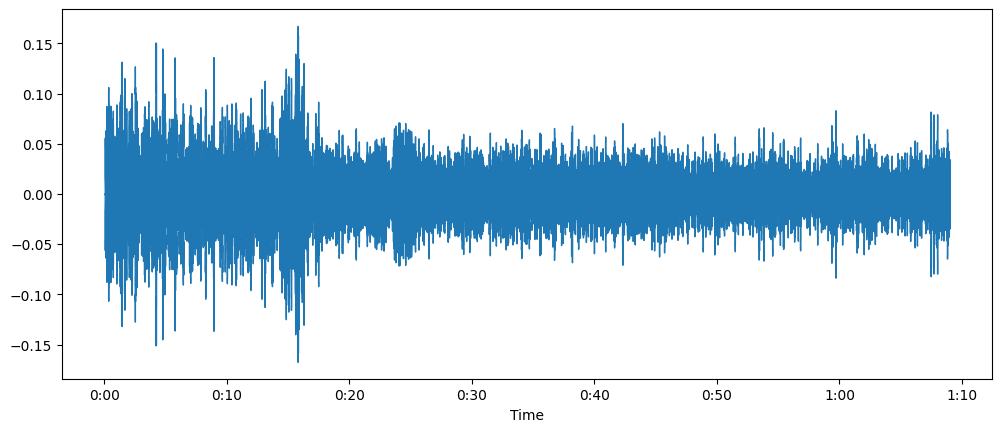

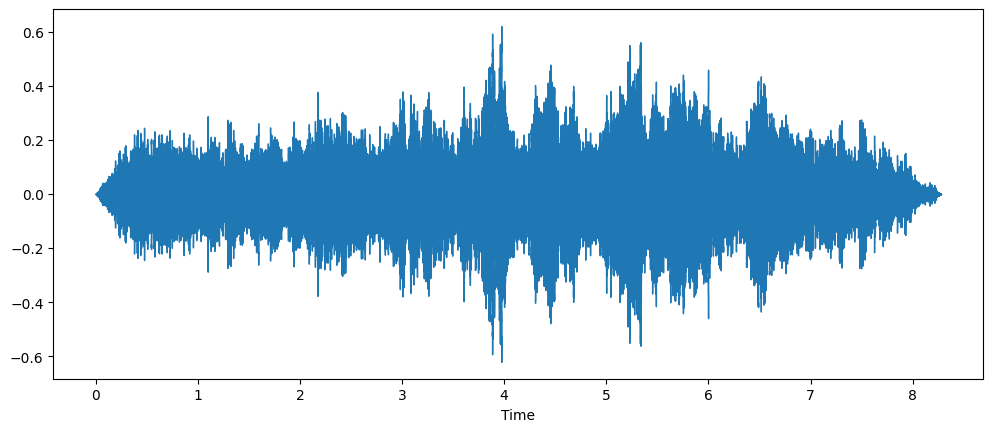

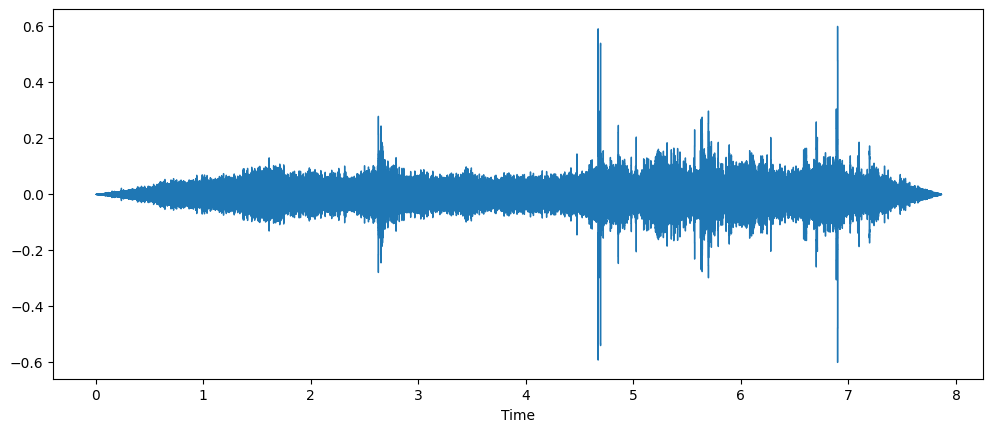

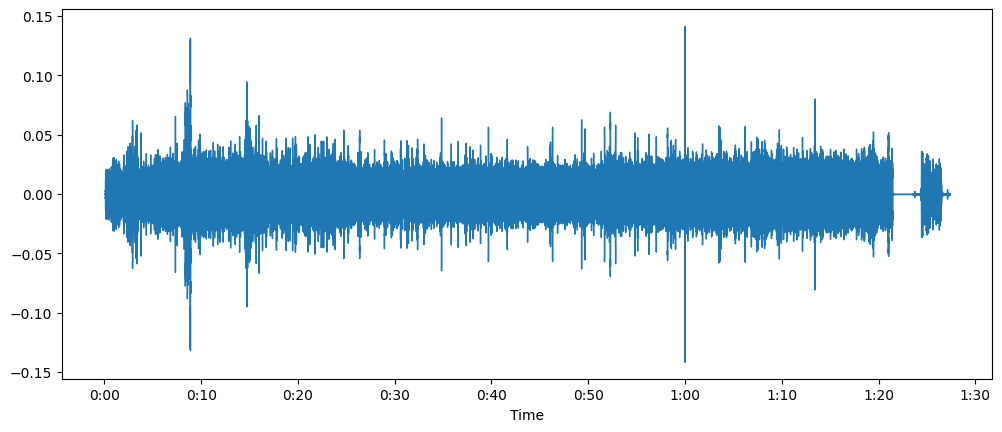

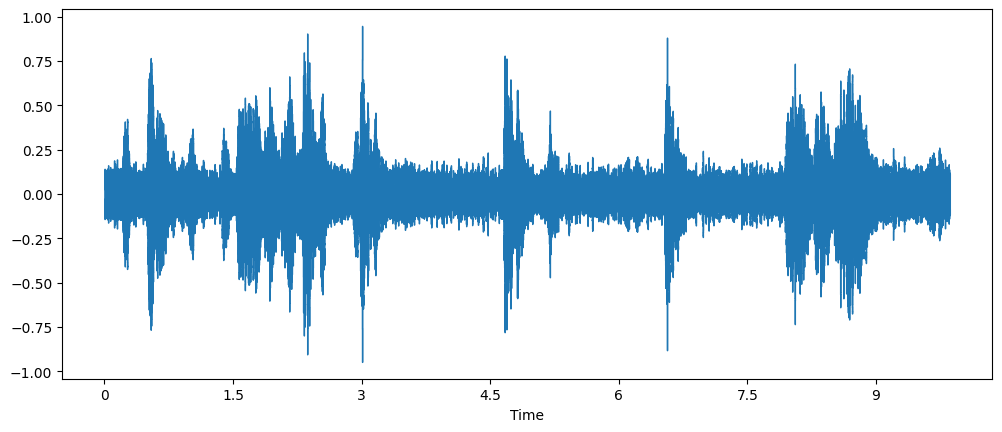

In [12]:
audio_segments = []

for i in range(5):
    path = df.sample(1)['audio_path'].values[0]
    y, sr = librosa.load(path, sr=None, mono=True)
    plt.figure().set_figwidth(12)
    librosa.display.waveshow(y, sr=sr)
    plt.show()
    
    # Guardar el archivo de audio en un objeto diferente
    audio = AudioSegment.from_file(path, "mp3")
    audio_segments.append(audio)

In [13]:
audio_segments[0]

In [14]:
audio_segments[1]

In [15]:
audio_segments[2]

In [16]:
audio_segments[3]

In [17]:
audio_segments[4]

In [18]:
#filtrar las especies que tengan mas de 30 cantos
df = df.groupby('Specie').filter(lambda x: len(x) >= 15)
df['Suborder'].value_counts()

Suborder
tiranni           44980
passeri           33291
Falconiformes       607
Piciformes          586
Psittaciformes      244
Name: count, dtype: int64

In [19]:
df = df.rename(columns={'Specie':'label', 'Path': 'audio_path'})
df = df.reset_index(drop=True)
df.shape

(79708, 5)

In [20]:
from sklearn.model_selection import StratifiedShuffleSplit

X = df.drop(columns=['label'])
y = df['label']

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)

for train_index, test_index in sss.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y[train_index], y[test_index]

In [21]:
X_train['label'] = y_train
X_test['label'] = y_test

/var/folders/_1/9ctwy_pn6bv2hyw11l_gqhm9855lbl/T/ipykernel_38303/2141970401.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['label'] = y_train
/var/folders/_1/9ctwy_pn6bv2hyw11l_gqhm9855lbl/T/ipykernel_38303/2141970401.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['label'] = y_test


In [22]:
# guardar el dataframe en un archivo csv
df.to_csv('/Users/camcortes/Documents/birds-sounds/data/paths_cantos_passeriformes.csv', index=False)
X_train.to_csv('/Users/camcortes/Documents/birds-sounds/data/train_specie.csv', index=False)
X_test.to_csv('/Users/camcortes/Documents/birds-sounds/data/test_specie.csv', index=False)

# muestra del df
muestra = X_train.sample(4000, random_state=42)
muestra = muestra.groupby('label').filter(lambda x: len(x) >= 10)

In [23]:
# split de los datos en train y test para el modelo 
from sklearn.model_selection import train_test_split
X_train_muestra, X_test_muestra = train_test_split(
    muestra, 
    test_size=0.4, 
    random_state=42,
    stratify=muestra['label']
    )

# split de validacion
X_val_muestra, X_test_muestra = train_test_split(
    X_test_muestra, 
    test_size=0.3, 
    random_state=42,
    stratify=X_test_muestra['label']
    )

In [24]:
# labels unicos en los datos
print(X_train_muestra['label'].nunique())
print(X_test_muestra['label'].nunique())
print(X_val_muestra['label'].nunique())

102
102
102


In [25]:
# dimensiones de los datos
print(X_train_muestra.shape)
print(X_val_muestra.shape)
print(X_test_muestra.shape)

(798, 5)
(373, 5)
(160, 5)


In [ ]:
X_val_muestra.to_csv('/Users/camcortes/Documents/birds-sounds/data/val_muestra.csv', index=False)
X_train_muestra.to_csv('/Users/camcortes/Documents/birds-sounds/data/train_muestra.csv', index=False)
X_test_muestra.to_csv('/Users/camcortes/Documents/birds-sounds/data/test_muestra.csv', index=False)